In [2]:
!pip install cupy-cuda12x
!pip install pyopencl
!apt-get install -y ocl-icd-opencl-dev
!nvcc --version

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ocl-icd-opencl-dev is already the newest version (2.2.14-3).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
import os
import cv2
import numpy as np
import cupy as cp
import time
from google.colab import files
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
def create_image(resolution: tuple):
  x = np.linspace(0, 255, resolution[1], dtype=np.uint8)
  y = np.linspace(0, 255, resolution[0], dtype=np.uint8)

  r_channel = np.outer(y, np.ones_like(x))
  g_channel = np.outer(np.ones_like(y), x)
  b_channel_float = np.outer(y, x)
  b_channel = (b_channel_float / 255.0).astype(np.uint8)

  image = np.stack([r_channel.astype(np.uint8), g_channel.astype(np.uint8), b_channel], axis=2)

  return image

In [5]:
def save_image(image, filename):
  image_cpu = cp.asnumpy(image)

  if '.' not in filename:
    filename = f"{filename}.png"
  else:
    filename = filename

  output_path = f"/content/drive/MyDrive/output/{filename}"
  os.makedirs("/content/drive/MyDrive/output", exist_ok=True)

  cv2.imwrite(output_path, cv2.cvtColor(image_cpu, cv2.COLOR_RGB2BGR))

  return output_path

In [6]:
def verify_saved_image():
    file_path = "/content/drive/MyDrive/output/test.png"

    if os.path.exists(file_path):
        print(f"Файл: {file_path}")
        print(f"Размер файла: {os.path.getsize(file_path) / (1024*1024):.2f} MB")

        # Читаем изображение обратно
        img = cv2.imread(file_path)
        if img is not None:
            print(f"Прочитано изображение: {img.shape}")
            print(f"Тип данных: {img.dtype}")
            print(f"Реальное разрешение: {img.shape[1]}x{img.shape[0]}")
        else:
            print("Не удалось прочитать изображение")
    else:
        print("Файл не найден")

In [7]:
def test_main():
    image = create_image(resolution=(10240, 7680))

    save_image(image, "test")

    del image
    cp.get_default_memory_pool().free_all_blocks()


if __name__ == "__main__":
    test_main()
    verify_saved_image()

Файл: /content/drive/MyDrive/output/test.png
Размер файла: 3.45 MB
Прочитано изображение: (10240, 7680, 3)
Тип данных: uint8
Реальное разрешение: 7680x10240


## Программа А

In [33]:
from cupyx.scipy.ndimage import convolve


BIAS = (300, 300)
FILL_COLOR = (187, 38, 73)
KERNEL_SIZE = 3


def process_image_cuda(img_cpu):
    h, w = img_cpu.shape[:2]
    dx, dy = BIAS

    img_gpu = cp.asarray(img_cpu, dtype=cp.uint8)
    color = cp.array(FILL_COLOR, dtype=cp.uint8)

    shifted_gpu = cp.full((h, w, 3), color, dtype=cp.uint8)

    src_x1 = max(dx, 0)
    src_y1 = max(dy, 0)
    src_x2 = w - max(-dx, 0)
    src_y2 = h - max(-dy, 0)

    dst_x1 = max(-dx, 0)
    dst_y1 = max(-dy, 0)
    dst_x2 = w - max(dx, 0)
    dst_y2 = h - max(dy, 0)

    shifted_gpu[dst_y1:dst_y2, dst_x1:dst_x2] = img_gpu[src_y1:src_y2, src_x1:src_x2]

    kernel = cp.ones((KERNEL_SIZE, KERNEL_SIZE), dtype=cp.float32) / (KERNEL_SIZE * KERNEL_SIZE)
    blurred_gpu = cp.zeros_like(shifted_gpu, dtype=cp.float32)

    for i in range(3):
        blurred_gpu[:, :, i] = convolve(shifted_gpu[:, :, i], kernel, mode='constant', cval=0.0)

    blurred_gpu = cp.clip(blurred_gpu, 0, 255).astype(cp.uint8)
    return blurred_gpu

def clear_gpu_memory():
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()


начало обработки: 10240x7680
Время: 0.3553 сек
Время: 0.3338 сек
Время: 0.3318 сек

Среднее время: 0.3403 сек


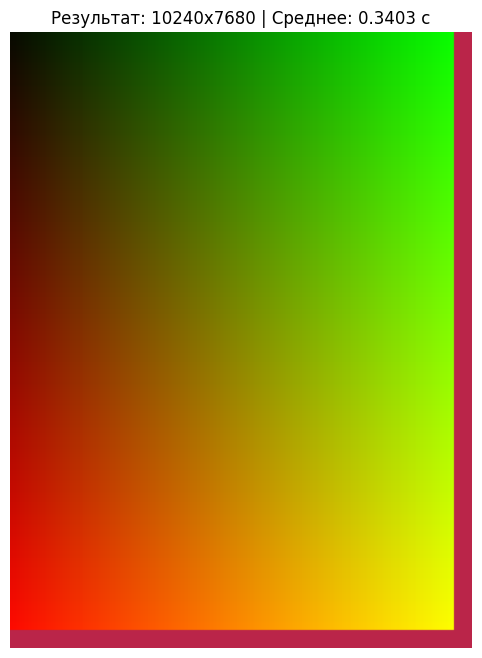


начало обработки: 12800x9600
Время: 0.5976 сек
Время: 0.5789 сек
Время: 0.6500 сек

Среднее время: 0.6088 сек


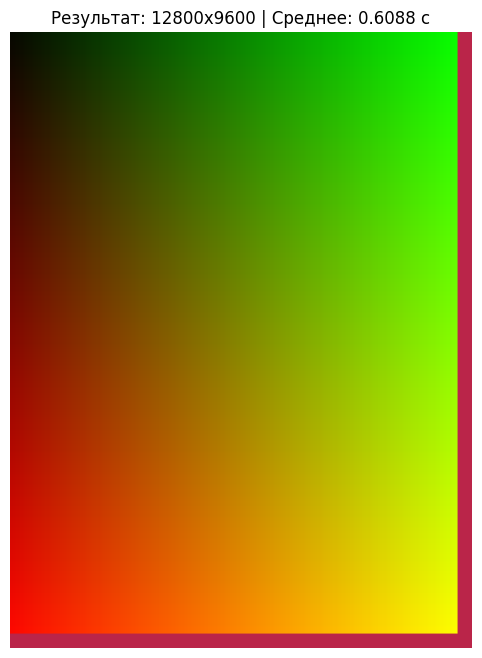


начало обработки: 20480x15360
Время: 1.8148 сек
Время: 2.0801 сек
Время: 1.5773 сек

Среднее время: 1.8241 сек


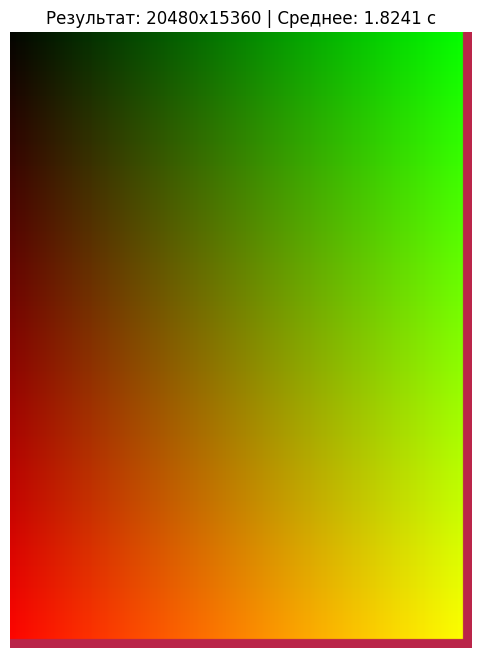


Результаты
Размер       | Среднее время (с)
------------------------------
10240x7680 | 0.3403
12800x9600 | 0.6088
20480x15360 | 1.8241


In [34]:
import gc;

SIZES = [(10240, 7680), (12800, 9600), (20480, 15360)]

results = []

for size in SIZES:
    print(f"\n" + "="*100)
    print(f"начало обработки: {size[0]}x{size[1]}")
    print("="*100)

    img_cpu = create_image(size)

    times = []
    final_result_cpu = None

    for i in range(3):
        clear_gpu_memory()
        gc.collect()

        start = time.time()
        try:
            result_gpu = process_image_cuda(img_cpu)
            result_cpu = cp.asnumpy(result_gpu)
            end = time.time()
            run_time = end - start
            times.append(run_time)
            print(f"Время: {run_time:.4f} сек")

            if i == 2:
                final_result_cpu = result_cpu.copy()

            del result_gpu
            clear_gpu_memory()

        except cp.cuda.memory.OutOfMemoryError:
            print("Ошибка: Не хватает памяти GPU!")
            times.append(float('inf'))

    valid_times = [t for t in times if t != float('inf')]
    if valid_times:
        avg_time = np.mean(valid_times)
        print(f"\nСреднее время: {avg_time:.4f} сек")
        results.append((size, avg_time))

    if final_result_cpu is not None:
        scale = 8 if size[0] > 5000 else (4 if size[0] > 2000 else 1)
        h, w = final_result_cpu.shape[:2]
        display_img = cv2.resize(final_result_cpu, (w // scale, h // scale))

        save_image(final_result_cpu, f"{size[0]}x{size[1]}")

        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(display_img, cv2.IMREAD_COLOR_BGR))
        plt.title(f"Результат: {size[0]}x{size[1]} | Среднее: {avg_time:.4f} с")
        plt.axis('off')
        plt.show()

    del img_cpu
    if final_result_cpu is not None:
        del final_result_cpu
    clear_gpu_memory()
    gc.collect()

print("\n" + "="*100)
print("Результаты")
print("="*10)
print(f"{'Размер':<12} | {'Среднее время (с)'}")
print("-" * 30)
for size, t in results:
    print(f"{size[0]}x{size[1]} | {t:.4f}" if not np.isnan(t) else f"{size[0]}x{size[1]} | Ошибка")

## Программа Б

In [35]:
kernel = """
__kernel void cross_scale_subtract(
    __global const uchar *orig,
    __global const uchar *small,
    __global uchar *result,
    const int orig_w,
    const int orig_h,
    const int small_w,
    const int small_h
) {
    int idx = get_global_id(0);
    int idy = get_global_id(1);
    if (idx >= orig_w || idy >= orig_h) return;

    int block_x = idx / 4;
    int block_y = idy / 4;
    block_x = min(block_x, small_w - 1);
    block_y = min(block_y, small_h - 1);

    int small_idx = block_y * small_w + block_x;

    for (int c = 0; c < 3; c++) {
        int val_orig = orig[idy * orig_w * 3 + idx * 3 + c];
        int val_small = small[small_idx * 3 + c];
        int res = val_orig - val_small;
        res = res < 0 ? 0 : res;
        res = res > 255 ? 255 : res;
        result[idy * orig_w * 3 + idx * 3 + c] = (uchar)res;
    }
}
"""

In [41]:
import pyopencl as cl

SCALE = 4
TRIALS = 3

platform = cl.get_platforms()[0]
device = platform.get_devices()[0]
context = cl.Context([device])
queue = cl.CommandQueue(context)

program = cl.Program(context, kernel).build()

knl = program.cross_scale_subtract

In [42]:
def process_cross_subtract(orig, small):
    h, w = orig.shape[:2]
    sh, sw = small.shape[:2]

    orig_flat = orig.astype(np.uint8)
    small_flat = small.astype(np.uint8)
    result_flat = np.zeros_like(orig_flat)

    mf = cl.mem_flags
    orig_buf = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=orig_flat)
    small_buf = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=small_flat)
    result_buf = cl.Buffer(context, mf.WRITE_ONLY, result_flat.nbytes)

    global_size = (w, h)
    knl(
        queue, global_size, None,
        orig_buf, small_buf, result_buf,
        np.int32(w), np.int32(h),
        np.int32(sw), np.int32(sh)
    )

    cl.enqueue_copy(queue, result_flat, result_buf)
    return result_flat.reshape(h, w, 3)


начало обработки: 10240x7680
Время: 0.4933 сек
Время: 0.4822 сек
Время: 0.4377 сек

Среднее время: 1.8241 сек
Min: 0
Max: 1
Mean: 0.011490512424045139


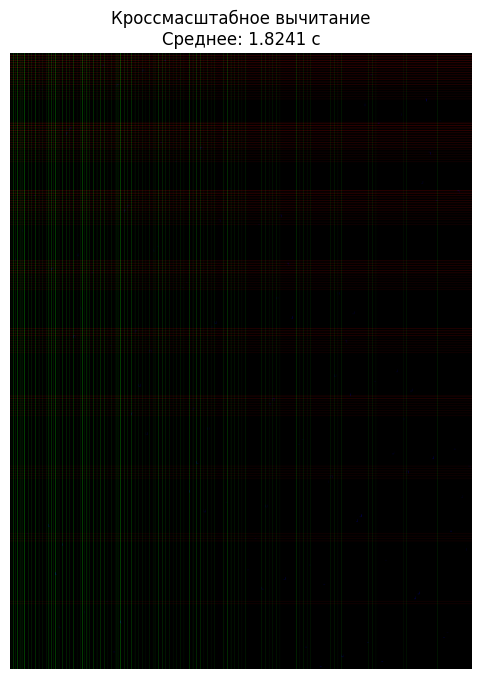


начало обработки: 12800x9600
Время: 0.6419 сек
Время: 0.6416 сек
Время: 0.6413 сек

Среднее время: 1.8241 сек
Min: 0
Max: 1
Mean: 0.008914946831597222


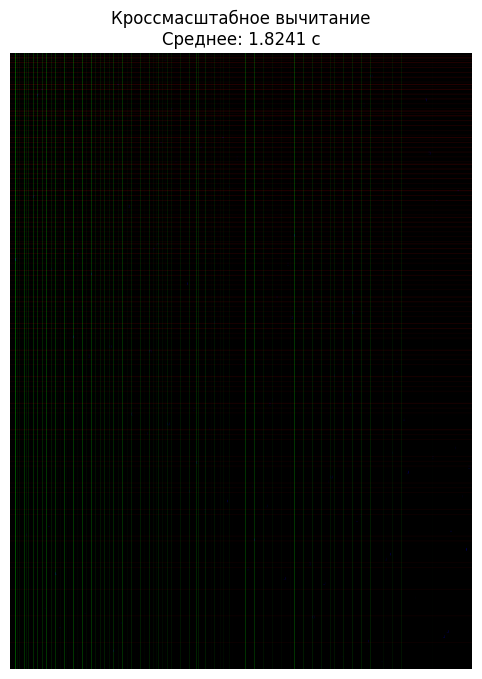


начало обработки: 20480x15360
Время: 1.6741 сек
Время: 1.6649 сек
Время: 1.6710 сек

Среднее время: 1.8241 сек
Min: 0
Max: 1
Mean: 0.005794926749335395


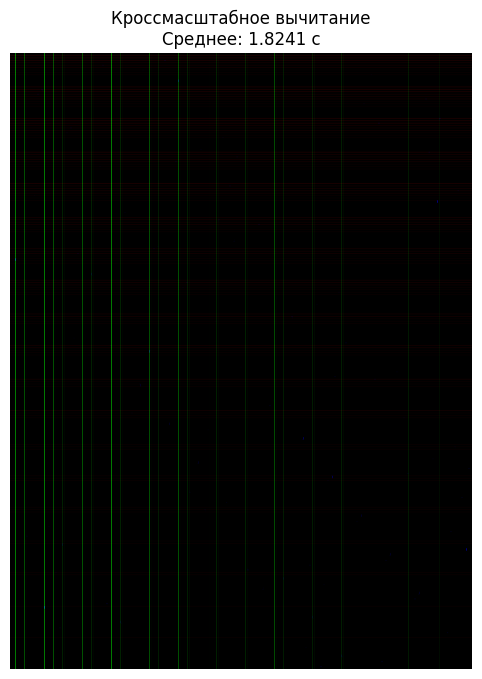


Результаты
Размер       | Среднее время (с)
------------------------------
10240x7680 | 1.8241
12800x9600 | 1.8241
20480x15360 | 1.8241


In [46]:
results = []

for size in SIZES:
    print(f"\n" + "="*100)
    print(f"начало обработки: {size[0]}x{size[1]}")
    print("="*100)

    orig = create_image(size)
    small = create_image((size[0] // SCALE, size[1] // SCALE))
    result_img = None

    times = []

    for i in range(TRIALS):
      clear_gpu_memory()
      start = time.time()
      result_img = process_cross_subtract(orig, small)
      end = time.time()
      t = end - start
      times.append(t)
      print(f"Время: {t:.4f} сек")

    avg_time = np.mean(valid_times)
    print(f"\nСреднее время: {avg_time:.4f} сек")
    results.append((size, avg_time))

    print("Min:", result_img.min())
    print("Max:", result_img.max())
    print("Mean:", result_img.mean())
    # display_img = cv2.normalize(result_img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    display_img = cv2.resize(result_img, (0, 0), fx=0.1, fy=0.1)
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(display_img, cv2.IMREAD_COLOR_BGR))
    plt.title(f"Кроссмасштабное вычитание\nСреднее: {avg_time:.4f} с")
    plt.axis('off')
    plt.show()

    del orig, small, result_img
    clear_gpu_memory()
    gc.collect()


print("\n" + "="*100)
print("Результаты")
print("="*100)
print(f"{'Размер':<12} | {'Среднее время (с)'}")
print("-" * 30)
for size, t in results:
    print(f"{size[0]}x{size[1]} | {t:.4f}" if not np.isnan(t) else f"{size[0]}x{size[1]} | Ошибка")